# 02 - Foundation Model Pre-Training

Train the AeroConform trajectory foundation model using self-supervised
next-patch prediction with a Gaussian mixture output head.

The model learns to predict the next patch of delta-encoded ADS-B state
vectors as a mixture of Gaussians, capturing both the expected trajectory
and its uncertainty.

## Optional: Mount Google Drive (Colab)

Uncomment the cell below if running on Colab to persist checkpoints.

## Setup and Configuration

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from aeroconform.config import AeroConformConfig

config = AeroConformConfig(
    pretrain_epochs=2,
    pretrain_batch_size=16,
    pretrain_warmup_steps=10,
    early_stopping_patience=5,
    gradient_accumulation_steps=1,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Epochs: {config.pretrain_epochs}")
print(f"Batch size: {config.pretrain_batch_size}")
print(f"d_model={config.d_model}, n_heads={config.n_heads}, n_layers={config.n_layers}")

Device: cpu
Epochs: 2
Batch size: 16
d_model=256, n_heads=8, n_layers=6


## Generate Synthetic Training Data

Create synthetic ADS-B trajectories, preprocess them through the full
pipeline, and build a PyTorch dataset.

In [2]:
import pandas as pd
from aeroconform.data.preprocessing import preprocess_pipeline
from aeroconform.data.dataset import TrajectoryDataset

rng = np.random.default_rng(42)


def generate_synthetic_trajectory(n_steps: int, rng: np.random.Generator) -> np.ndarray:
    """Generate a single realistic synthetic ADS-B trajectory."""
    lat = rng.uniform(config.bbox[0], config.bbox[1])
    lon = rng.uniform(config.bbox[2], config.bbox[3])
    alt = rng.uniform(15000, 40000)
    vel = rng.uniform(200, 500)
    hdg = rng.uniform(0, 360)
    vrate = 0.0
    traj = np.zeros((n_steps, 6))
    for t in range(n_steps):
        traj[t] = [lat, lon, alt, vel, hdg, vrate]
        lat += vel * np.cos(np.radians(hdg)) / 3600 / 60
        lon += vel * np.sin(np.radians(hdg)) / 3600 / 60 / np.cos(np.radians(lat))
        alt += vrate / 60
        vel = np.clip(vel + rng.normal(0, 1), 150, 600)
        hdg = (hdg + rng.normal(0, 0.3)) % 360
        vrate = rng.normal(0, 50)
    return traj


# Generate trajectories and build DataFrame
n_trajectories = 50
rows = []
for i in range(n_trajectories):
    traj = generate_synthetic_trajectory(200, rng)
    icao24 = f"ac{i:04d}"
    for t in range(len(traj)):
        rows.append({
            "icao24": icao24, "timestamp": t,
            "latitude": traj[t, 0], "longitude": traj[t, 1],
            "baro_altitude": traj[t, 2], "velocity": traj[t, 3],
            "true_track": traj[t, 4], "vertical_rate": traj[t, 5],
            "on_ground": False,
        })

states_df = pd.DataFrame(rows)
all_windows, norm_stats = preprocess_pipeline(states_df, config)
dataset = TrajectoryDataset(all_windows, config=config)

print(f"Trajectories: {n_trajectories}")
print(f"Windows: {len(all_windows)}")
print(f"Dataset size: {len(dataset)}")

2026-04-13 21:23:37 [info     ] trajectories_extracted         count=50


2026-04-13 21:23:37 [info     ] preprocessing_complete         trajectories=50 windows=150


Trajectories: 50
Windows: 150
Dataset size: 150


## Instantiate the Trajectory Transformer

The model architecture:
- **PatchTokenizer**: groups P timesteps into patches, projects to d_model
- **Sinusoidal positional encoding**: for length generalization
- **Causal transformer decoder**: pre-norm layers with GELU activation
- **Gaussian mixture head**: predicts (means, log_vars, log_weights)

In [3]:
from aeroconform.models.trajectory_model import TrajectoryTransformer

model = TrajectoryTransformer.from_config(config)
n_params = sum(p.numel() for p in model.parameters())

print(f"Model parameters: {n_params:,}")
print(f"Architecture:")
print(f"  Tokenizer: input_dim={config.input_dim}, patch_len={config.patch_len} -> d_model={config.d_model}")
print(f"  Transformer: {config.n_layers} layers, {config.n_heads} heads, d_ff={config.d_ff}")
print(f"  GMM Head: {config.n_components} components, output_dim={config.output_dim}")

Model parameters: 6,458,341
Architecture:
  Tokenizer: input_dim=6, patch_len=8 -> d_model=256
  Transformer: 6 layers, 8 heads, d_ff=1024
  GMM Head: 5 components, output_dim=48


## Verify Forward Pass

Confirm the model produces the expected output shapes before training.

In [4]:
# Test forward pass
sample = dataset[0]
x = sample["input"].unsqueeze(0)  # (1, 128, 6)
print(f"Input shape: {x.shape}")

model.eval()
with torch.no_grad():
    means, log_vars, log_weights, hidden = model(x)

print(f"\nOutput shapes:")
print(f"  means:       {means.shape}  (batch, num_patches, n_components, output_dim)")
print(f"  log_vars:    {log_vars.shape}")
print(f"  log_weights: {log_weights.shape}  (batch, num_patches, n_components)")
print(f"  hidden:      {hidden.shape}  (batch, num_patches, d_model)")

# Verify shapes
assert means.shape == (1, config.num_patches, config.n_components, config.output_dim)
assert log_weights.shape == (1, config.num_patches, config.n_components)
assert hidden.shape == (1, config.num_patches, config.d_model)
print("\nAll shape checks passed.")

Input shape: torch.Size([1, 128, 6])

Output shapes:
  means:       torch.Size([1, 16, 5, 48])  (batch, num_patches, n_components, output_dim)
  log_vars:    torch.Size([1, 16, 5, 48])
  log_weights: torch.Size([1, 16, 5])  (batch, num_patches, n_components)
  hidden:      torch.Size([1, 16, 256])  (batch, num_patches, d_model)

All shape checks passed.


## Run Pre-Training

Train for 2 epochs on synthetic data using the pre-training loop.
The training uses:
- AdamW optimizer with cosine warmup LR schedule
- Gaussian mixture NLL loss
- Gradient clipping at max_grad_norm=1.0
- Train/val split for early stopping

In [5]:
from torch.utils.data import DataLoader, random_split
from aeroconform.training.utils import get_cosine_warmup_scheduler, clip_gradients

model = TrajectoryTransformer.from_config(config).to(device)
model.train()

# Train/val split
val_size = max(1, int(len(dataset) * config.val_fraction))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=config.pretrain_batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=config.pretrain_batch_size, shuffle=False, num_workers=0)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=config.pretrain_lr,
    weight_decay=config.pretrain_weight_decay, betas=(0.9, 0.95),
)

total_steps = len(train_loader) * config.pretrain_epochs
scheduler = get_cosine_warmup_scheduler(optimizer, config.pretrain_warmup_steps, total_steps)

print(f"Training set: {train_size} samples")
print(f"Validation set: {val_size} samples")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Total steps: {total_steps}")

# Training loop
train_losses = []
val_losses = []

for epoch in range(config.pretrain_epochs):
    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for batch in train_loader:
        x = batch["input"].to(device)
        target = batch["target"].to(device)

        means, log_vars, log_weights, _ = model(x)
        loss = model.output_head.nll_loss(means, log_vars, log_weights, target)

        optimizer.zero_grad()
        loss.backward()
        clip_gradients(model, config.max_grad_norm)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_loss / max(1, n_batches)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch["input"].to(device)
            target = batch["target"].to(device)
            means, log_vars, log_weights, _ = model(x)
            loss = model.output_head.nll_loss(means, log_vars, log_weights, target)
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / max(1, val_batches)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{config.pretrain_epochs} - "
          f"Train loss: {avg_train_loss:.4f}, Val loss: {avg_val_loss:.4f}, "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

print("\nTraining complete.")

Training set: 135 samples
Validation set: 15 samples
Batches per epoch: 9
Total steps: 18


Epoch 1/2 - Train loss: 178.3422, Val loss: 97.8691, LR: 0.000270


Epoch 2/2 - Train loss: 93.1712, Val loss: 88.0420, LR: 0.000000

Training complete.


## Plot Training Loss

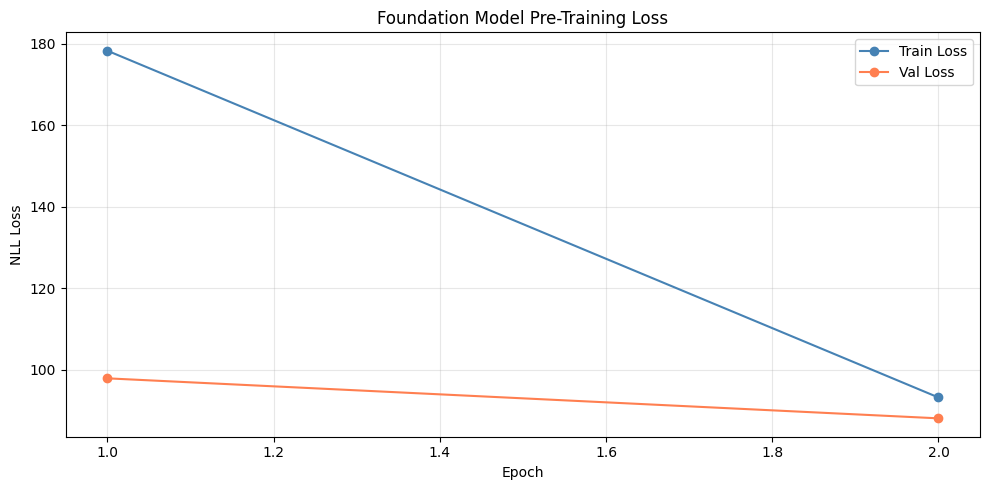

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, "o-", label="Train Loss", color="steelblue")
ax.plot(epochs_range, val_losses, "o-", label="Val Loss", color="coral")

ax.set_xlabel("Epoch")
ax.set_ylabel("NLL Loss")
ax.set_title("Foundation Model Pre-Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Inspect Predictions

Examine what the trained model predicts: mixture component weights
and the most likely next-patch prediction.

Mixture weights for first patch prediction:
  Component 0: weight=0.0003
  Component 1: weight=0.0480
  Component 2: weight=0.9499
  Component 3: weight=0.0015
  Component 4: weight=0.0002


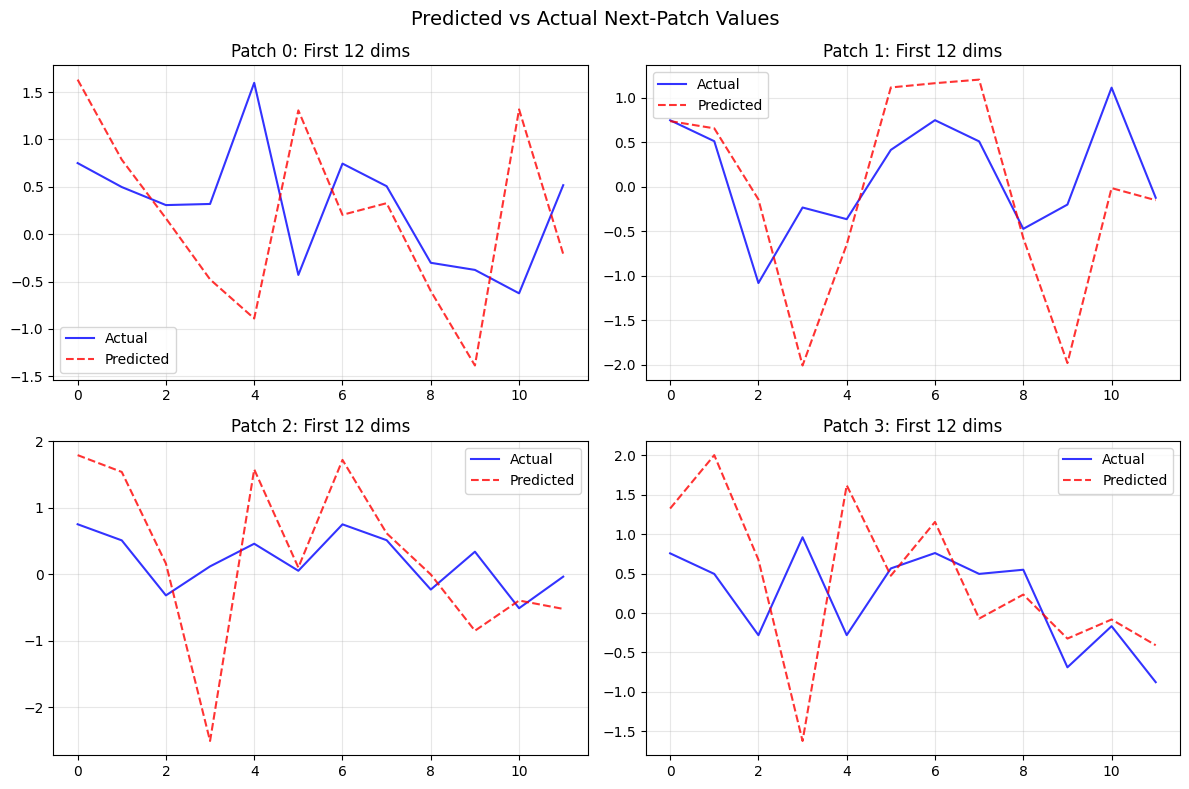

In [7]:
model.eval()
sample = dataset[0]
x = sample["input"].unsqueeze(0).to(device)
target = sample["target"].unsqueeze(0).to(device)

with torch.no_grad():
    means, log_vars, log_weights, hidden = model(x)

# Examine mixture weights for the first patch
weights = torch.exp(log_weights[0, 0]).cpu().numpy()
print("Mixture weights for first patch prediction:")
for k in range(config.n_components):
    print(f"  Component {k}: weight={weights[k]:.4f}")

# Plot predicted vs actual for first few patches
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for patch_idx, ax in zip(range(4), axes.flat):
    actual = target[0, patch_idx].cpu().numpy()
    # Weighted mean prediction across components
    w = torch.exp(log_weights[0, patch_idx]).cpu().numpy()
    pred = (means[0, patch_idx].cpu().numpy() * w[:, None]).sum(axis=0)

    ax.plot(actual[:12], "b-", label="Actual", alpha=0.8)
    ax.plot(pred[:12], "r--", label="Predicted", alpha=0.8)
    ax.set_title(f"Patch {patch_idx}: First 12 dims")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Predicted vs Actual Next-Patch Values", fontsize=14)
plt.tight_layout()
plt.show()

## Extract Trajectory Embeddings

The last hidden state serves as a trajectory embedding for the graph layer.

In [8]:
model.eval()
x = sample["input"].unsqueeze(0).to(device)

with torch.no_grad():
    embedding = model.get_trajectory_embedding(x)

print(f"Trajectory embedding shape: {embedding.shape}  (batch, d_model)")
print(f"Embedding norm: {embedding.norm().item():.4f}")
print(f"Embedding mean: {embedding.mean().item():.6f}")
print(f"Embedding std: {embedding.std().item():.6f}")

Trajectory embedding shape: torch.Size([1, 256])  (batch, d_model)
Embedding norm: 54.0711
Embedding mean: 0.204873
Embedding std: 3.379837


## Summary

This notebook demonstrated:

1. **Synthetic data generation** and preprocessing pipeline
2. **TrajectoryTransformer** architecture and forward pass verification
3. **2-epoch pre-training** with NLL loss, cosine warmup, and gradient clipping
4. **Training/validation loss** curves
5. **Prediction inspection**: mixture weights and predicted vs actual patches
6. **Trajectory embeddings** for downstream graph layer

Next: `03_graph_training.ipynb` trains the GATv2 graph attention layer.